In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import statsmodels.api as sm 

# Problem 1


### importing our data for analysis

In [15]:
# FF
FF = pd.read_csv('FF_allhistory.csv')

#Strategy returns (SR) 
SR = pd.read_excel("HW3_RD_ANALYSIS.xlsx", sheet_name="s.hedge-StatArb03-'04-'06")


In [16]:
FF['d'] = pd.to_datetime(FF['d'])
SR['Date'] = pd.to_datetime(SR['Date'])

FF.rename(columns={'d': 'Date'}, inplace=True)

SR = SR.set_index('Date')
FF = FF.set_index('Date')

In [17]:
SR.describe()

,WRTC
count,755.000000
mean,0.002476
std,0.009717
min,-0.029448
25%,-0.004210
50%,0.002852
75%,0.008426
max,0.034185


In [18]:
SR, FF

(                WRTC
 Date                
 2004-01-02  0.020868
 2004-01-05  0.009772
 2004-01-06  0.014941
 2004-01-07  0.020730
 2004-01-08  0.003681
 ...              ...
 2006-12-22  0.002729
 2006-12-26 -0.010757
 2006-12-27  0.003390
 2006-12-28  0.006580
 2006-12-29  0.014643
 
 [755 rows x 1 columns],
              mktrf     smb     hml      rf     umd
 Date                                              
 1926-07-01  0.0009 -0.0025 -0.0027  0.0001     NaN
 1926-07-02  0.0045 -0.0033 -0.0006  0.0001     NaN
 1926-07-06  0.0017  0.0030 -0.0039  0.0001     NaN
 1926-07-07  0.0009 -0.0058  0.0002  0.0001     NaN
 1926-07-08  0.0022 -0.0038  0.0019  0.0001     NaN
 ...            ...     ...     ...     ...     ...
 2025-11-21  0.0103  0.0166  0.0074  0.0002 -0.0166
 2025-11-24  0.0161  0.0030 -0.0096  0.0002  0.0233
 2025-11-25  0.0104  0.0165  0.0004  0.0002 -0.0102
 2025-11-26  0.0069 -0.0006 -0.0007  0.0002  0.0048
 2025-11-28  0.0054 -0.0042  0.0036  0.0002  0.0018
 
 [26129 r

In [19]:
DF = pd.merge(left=SR, right=FF, on='Date', how="inner")
DF

,WRTC,mktrf,smb,hml,rf,umd
Date,,,,,,
2004-01-02,0.020868,-0.0017,0.0081,0.0042,0.0000,0.0002
2004-01-05,0.009772,0.0120,0.0040,0.0001,0.0000,0.0055
2004-01-06,0.014941,0.0020,0.0009,0.0027,0.0000,0.0071
2004-01-07,0.020730,0.0034,0.0059,-0.0008,0.0000,0.0046
2004-01-08,0.003681,0.0045,0.0030,0.0072,0.0000,0.0031
...,...,...,...,...,...,...
2006-12-22,0.002729,-0.0048,0.0028,0.0007,0.0002,-0.0004
2006-12-26,-0.010757,0.0044,0.0032,0.0039,0.0002,0.0005
2006-12-27,0.003390,0.0074,0.0053,-0.0009,0.0002,0.0039


## Part (a): Annualized return, volatility, and Sharpe ratio

In [28]:
excess_ret = DF['WRTC'] - DF['rf']

n_days = 252

print(DF['WRTC'].mean())

ann_return = DF['WRTC'].mean() * n_days
ann_vol = DF['WRTC'].std() * np.sqrt(n_days)
ann_excess_vol = excess_ret.std() * np.sqrt(n_days)
ann_rf = DF['rf'].mean() * n_days
sharpe = (ann_return - ann_rf) / ann_excess_vol

print(f"Annualized Return:    {ann_return:.4f}  ({ann_return*100:.2f}%)")
print(f"Annualized Volatility:{ann_vol:.4f}  ({ann_vol*100:.2f}%)")
print(f"Annualized Rf:        {ann_rf:.4f}  ({ann_rf*100:.2f}%)")
print(f"Sharpe Ratio:         {sharpe:.4f}")

0.002476481486554075
Annualized Return:    0.6241  (62.41%)
Annualized Volatility:0.1543  (15.43%)
Annualized Rf:        0.0294  (2.94%)
Sharpe Ratio:         3.8528


## Part (b): CAPM Regression

In [26]:
X_capm = sm.add_constant(DF['mktrf'])
y = excess_ret

capm_nw = sm.OLS(y, X_capm).fit(cov_type='HAC', cov_kwds={'maxlags': int(np.floor(4 * (len(y)/100)**(2/9)))})

print("\n=== OLS (Newey-West standard errors) ===")
print(capm_nw.summary())

print("\n--- Key Results (Newey-West) ---")
print(f"Alpha (daily): {capm_nw.params['const']:.6f}  (t = {capm_nw.tvalues['const']:.3f}, p = {capm_nw.pvalues['const']:.4f})")
print(f"Beta:          {capm_nw.params['mktrf']:.4f}  (t = {capm_nw.tvalues['mktrf']:.3f}, p = {capm_nw.pvalues['mktrf']:.4f})")
print(f"R-squared:     {capm_nw.rsquared:.4f}")
print(f"\nAlpha annualized: {capm_nw.params['const'] * 252:.4f}  ({capm_nw.params['const'] * 252 * 100:.2f}%)")
print(f"Alpha is {'statistically significant' if capm_nw.pvalues['const'] < 0.05 else 'NOT statistically significant'} at 5% level (Newey-West).")


=== OLS (Newey-West standard errors) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.526
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.217
Time:                        17:09:01   Log-Likelihood:                 2428.2
No. Observations:                 755   AIC:                            -4852.
Df Residuals:                     753   BIC:                            -4843.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const     

## Part (c): Fama-French + Momentum (Carhart 4-Factor) Regression

In [27]:
factors = ['mktrf', 'smb', 'hml', 'umd']
X_ff = sm.add_constant(DF[factors])

ff4 = sm.OLS(y, X_ff).fit(cov_type='HAC', cov_kwds={'maxlags': int(np.floor(4 * (len(y)/100)**(2/9)))})
print(ff4.summary())

print("\n--- Key Results (Newey-West) ---")
for name in ['const'] + factors:
    label = 'Alpha' if name == 'const' else name
    print(f"{label:8s}: coef = {ff4.params[name]:9.6f},  SE = {ff4.bse[name]:.6f},  t = {ff4.tvalues[name]:7.3f},  p = {ff4.pvalues[name]:.4f}")

print(f"\nR-squared:        {ff4.rsquared:.4f}")
print(f"Alpha annualized: {ff4.params['const'] * 252:.4f}  ({ff4.params['const'] * 252 * 100:.2f}%)")
print(f"Alpha is {'statistically significant' if ff4.pvalues['const'] < 0.05 else 'NOT statistically significant'} at 5% level (Newey-West).")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.384
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.238
Time:                        17:14:36   Log-Likelihood:                 2430.6
No. Observations:                 755   AIC:                            -4851.
Df Residuals:                     750   BIC:                            -4828.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0024      0.000      6.864      0.0

## Part (d): Ranked Returns Plot and Winner/Loser Analysis

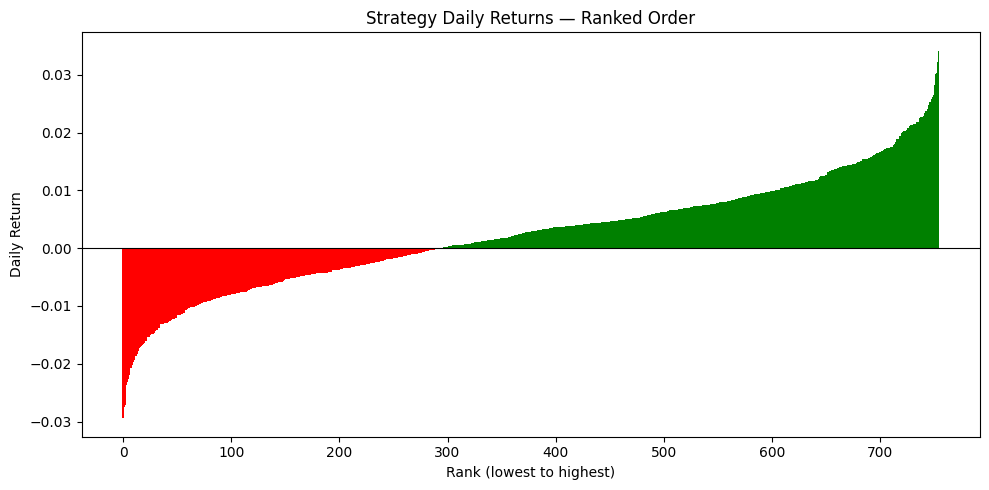

Total trading days:     755
Winners (ret > 0):      462  (61.2%)
Losers  (ret < 0):      293  (38.8%)
Zero-return days:       0

Median return of winners: 0.007016  (0.7016%)
Median return of losers:  -0.005830  (-0.5830%)


In [23]:
sorted_ret = DF['WRTC'].sort_values().values

plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_ret)), sorted_ret, width=1.0, color=np.where(sorted_ret >= 0, 'green', 'red'))
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Rank (lowest to highest)')
plt.ylabel('Daily Return')
plt.title('Strategy Daily Returns — Ranked Order')
plt.tight_layout()
plt.show()

winners = DF['WRTC'][DF['WRTC'] > 0]
losers = DF['WRTC'][DF['WRTC'] < 0]
n_total = len(DF)

frac_winners = len(winners) / n_total
frac_losers = len(losers) / n_total

print(f"Total trading days:     {n_total}")
print(f"Winners (ret > 0):      {len(winners)}  ({frac_winners*100:.1f}%)")
print(f"Losers  (ret < 0):      {len(losers)}  ({frac_losers*100:.1f}%)")
print(f"Zero-return days:       {n_total - len(winners) - len(losers)}")
print(f"\nMedian return of winners: {winners.median():.6f}  ({winners.median()*100:.4f}%)")
print(f"Median return of losers:  {losers.median():.6f}  ({losers.median()*100:.4f}%)")

## Part (e): Forward-Looking Analysis and Out-of-Sample Perspectives

2004:  Ann Return =  69.94%,  Ann Vol = 15.26%,  Sharpe = 4.51
2005:  Ann Return =  73.18%,  Ann Vol = 16.13%,  Sharpe = 4.37
2006:  Ann Return =  44.03%,  Ann Vol = 14.85%,  Sharpe = 2.63

--- Rolling 6-month Sharpe (annualized) ---


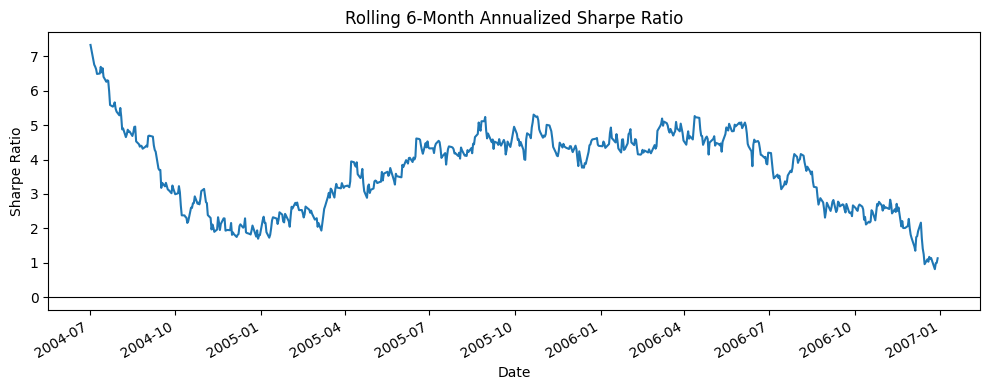

In [24]:
yearly = DF['WRTC'].groupby(DF.index.year)
for yr, grp in yearly:
    yr_ann_ret = grp.mean() * 252
    yr_ann_vol = grp.std() * np.sqrt(252)
    yr_rf = DF.loc[grp.index, 'rf'].mean() * 252
    yr_sharpe = (yr_ann_ret - yr_rf) / yr_ann_vol
    print(f"{yr}:  Ann Return = {yr_ann_ret*100:6.2f}%,  Ann Vol = {yr_ann_vol*100:5.2f}%,  Sharpe = {yr_sharpe:.2f}")

print("\n--- Rolling 6-month Sharpe (annualized) ---")
rolling_mean = DF['WRTC'].rolling(126).mean() * 252
rolling_vol = DF['WRTC'].rolling(126).std() * np.sqrt(252)
rolling_rf = DF['rf'].rolling(126).mean() * 252
rolling_sharpe = (rolling_mean - rolling_rf) / rolling_vol

plt.figure(figsize=(10, 4))
rolling_sharpe.plot()
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Rolling 6-Month Annualized Sharpe Ratio')
plt.ylabel('Sharpe Ratio')
plt.xlabel('Date')
plt.tight_layout()
plt.show()